## Visualising Differential Operators ##


Right, let us start with importing the required libraries. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Now let us define a function that generates a scalar field.

# Init

In [2]:
def scalar_gen(size, min_value, max_value):
    ''' 
    Parameters:
        size (tuple): Size of the scalar field (rows, columns).
        min_value (int or float): Minimum value for the scalar field.
        max_value (int or float): Maximum value for the scalar field.
        
     Returns:
        np.ndarray: 2D array randomly sampled from a uniform distribution between lo and hi.
    '''
   
    return np.random.uniform(min_value, max_value, size)


Let us test that out. We should be able to see a set of values that are returned from the function if we use a `print` command

In [3]:
a=10
b=10
lo=10
hi=100
scalar_field = scalar_gen(size=(a,b), min_value=lo, max_value=hi)
print(scalar_field)

[[23.72098868 18.99710967 35.81062802 38.89493643 90.9132751  71.53297204
  66.93256373 97.1994066  23.89303819 75.27679023]
 [88.16494437 70.8669731  70.45471392 63.25453218 39.24395783 88.4949766
  84.63232889 70.86567464 97.20496114 41.32020232]
 [75.71647899 79.51099003 81.6647064  22.69556909 71.21615656 96.89579428
  24.24724553 95.43267774 60.37304485 32.20237507]
 [79.63538341 52.98301627 58.27142436 52.3601887  52.03153409 34.28388602
  98.13981883 26.08365505 98.70495291 55.906442  ]
 [40.36816111 43.9424899  29.98862961 11.80601401 57.22556047 91.49563877
  62.7930771  27.33213569 33.04766752 35.65710008]
 [28.24145069 97.88512586 98.40539617 29.17714736 47.79024858 83.60099453
  41.31717712 97.01966481 81.34342372 31.35878857]
 [59.25795804 69.73238352 35.78360709 24.25448413 68.3594212  99.72376246
  94.64893518 62.07030028 83.51866747 55.62222595]
 [56.55366743 59.16609035 85.63772368 58.98647864 78.92414444 43.46203256
  75.73679827 77.36017114 98.52721895 45.35576994]
 

Looks good. Now we define a scalar visualiser that helps us visualise this output.

In [4]:
def scalar_vis(scalar_field):
    """
    Visualizes the given scalar field as a heatmap.
    
    Parameters:
        scalar_field (np.ndarray): 2D array representing the scalar field.
    """
    plt.figure(figsize=(a, b))
    plt.imshow(scalar_field, cmap='hot', interpolation='nearest')
    plt.colorbar(label='')
    plt.title('Scalar Field Heatmap')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.show()

And, let us see if the output!:

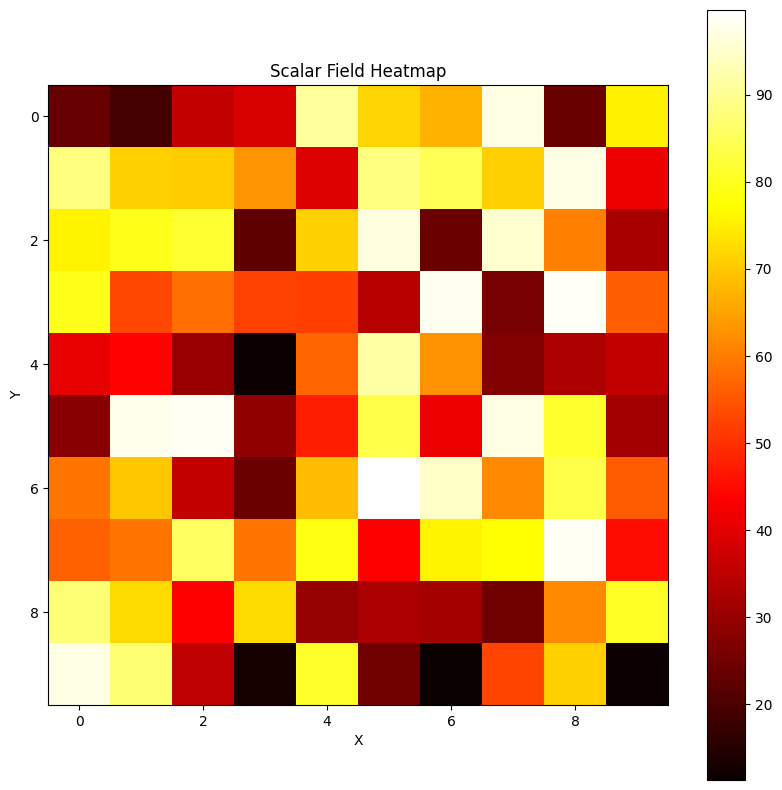

In [5]:
scalar_vis(scalar_field)

Let us now go ahead and do the same for vectors. We stick to 2D for now. Let us define a vector field generator, a totally random one at that.

In [6]:
def vector_gen(size):
   
    return np.random.randn(size[0], size[1]), np.random.randn(size[0], size[1])

Let us now define a vector visualiser function

In [7]:
def vector_vis(vector_field):
    x, y = vector_field
    plt.figure(figsize=(a, b))
    plt.quiver(x, y)
    plt.title('Vector Field')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.show()


And let us test that out

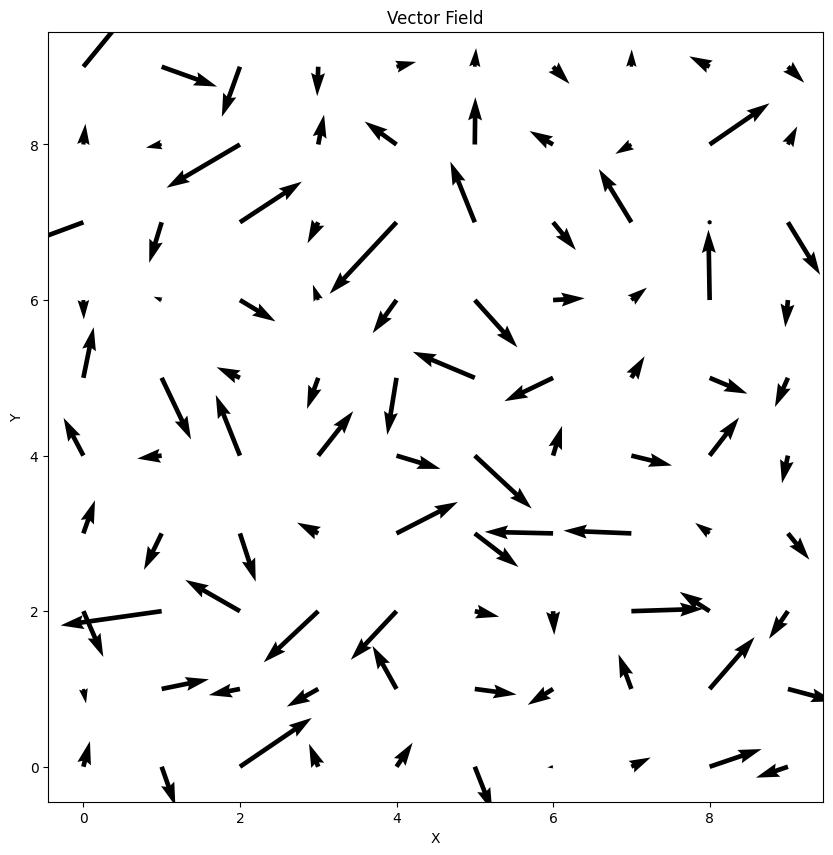

In [8]:
vector_field = vector_gen(size=(a,b))
vector_vis(vector_field)

Ok, now let ys go ahead and define a gradient calculator that accepts a scalar input and returns a 2D vector output.

In [9]:
def grad(scalar_field):
    gradient_x, gradient_y = np.gradient(scalar_field)
    return gradient_x, gradient_y

Time for initialisation and visualisation!

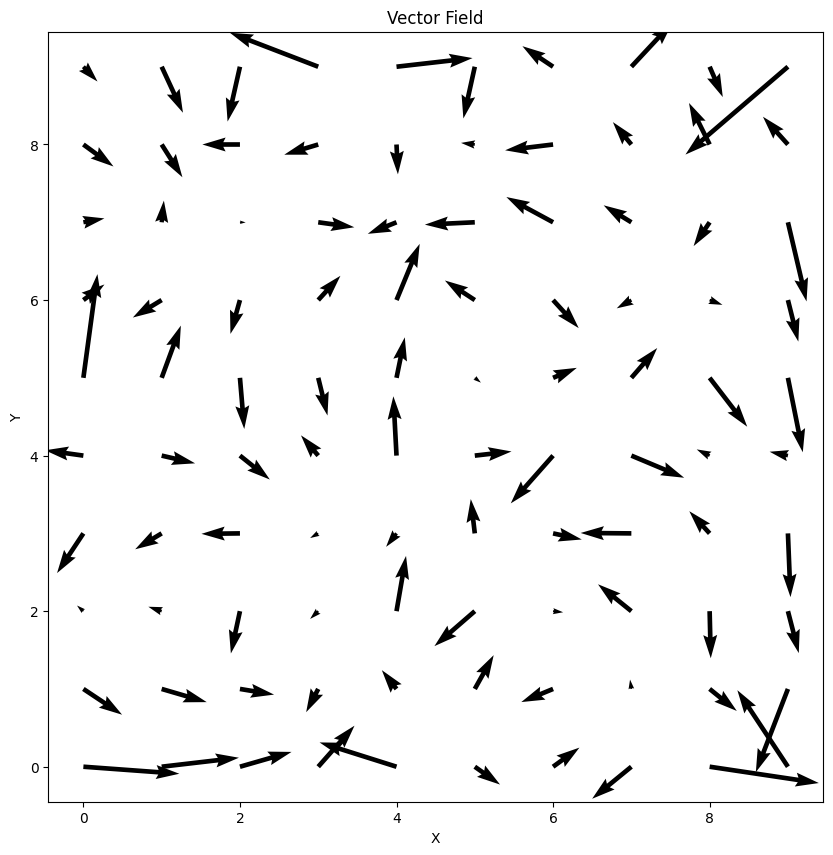

In [10]:
gradient_field=grad(scalar_field)
vector_vis(gradient_field)

Ok, looks good! Now let us define a divergence function

In [11]:
def div(vector_field):
    dx = np.gradient(vector_field[0])
    dy = np.gradient(vector_field[1])
    return dx[0] + dy[1]

Same drill! Initialise, Visualise!

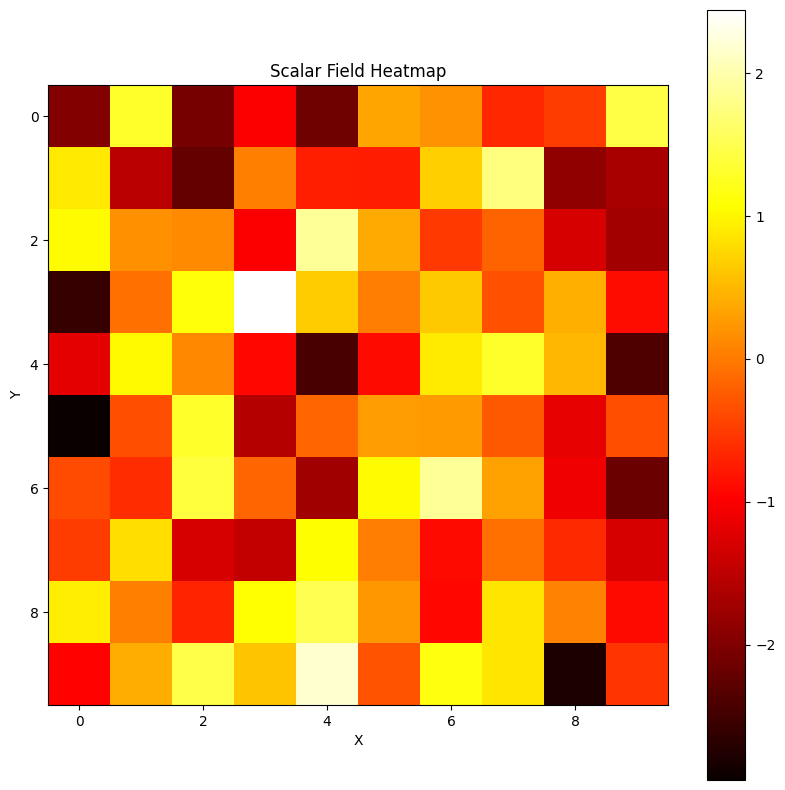

In [12]:
divergence_field=div(vector_field)
scalar_vis(divergence_field)

Not really helpful!, Let us try plotting the two together.

In [63]:
def visualiser(scalar_field, vector_field):
    x, y = vector_field
    plt.figure(figsize=(a, b))
    
    plt.quiver(x, y, color='white')
    plt.imshow(scalar_field, cmap='hot', interpolation='nearest')
    plt.colorbar(label='Value')
    plt.title('Scalar Field Heatmap')
    plt.xlabel('X')
    plt.ylabel('Y')
    
    plt.show()

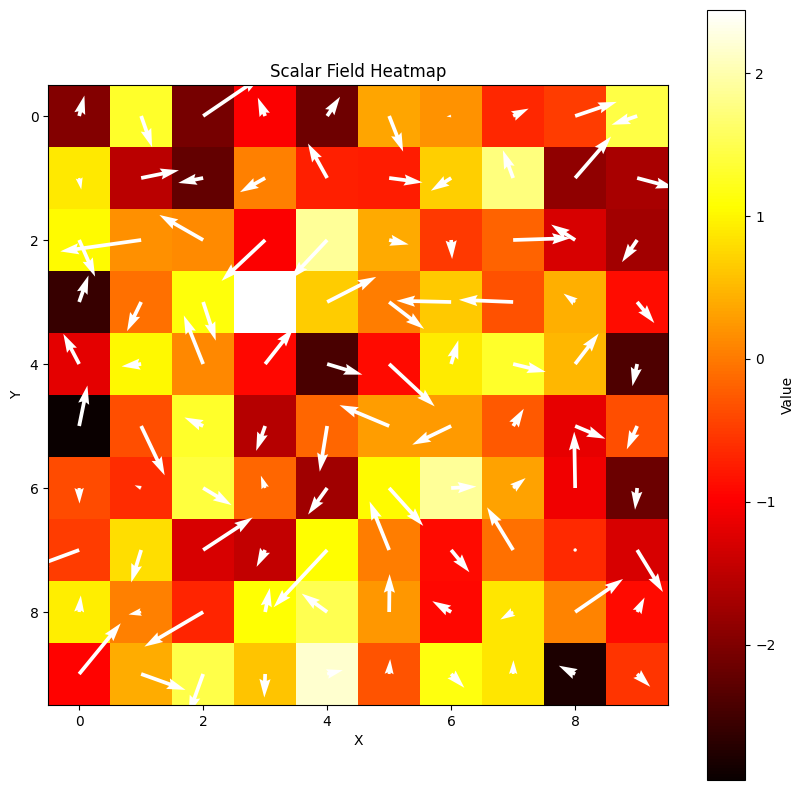

In [64]:
visualiser(divergence_field, vector_field)

# Functions
Not very insightful. Let us now try defining a specific type of scalar function and then starting from there. Let us try with generating a function that accepts an equation as a parameter

In [65]:
def scalar_gen2(size, equation):
    x = np.linspace(-1, 1, size[0])
    y = np.linspace(-1, 1, size[1])
    X, Y = np.meshgrid(x, y)
    scalar_field = eval(equation)
    return scalar_field


In [90]:
field_size = (50, 50)
equation = 'X**6 + 5*Y**6'
scalar_field2 = scalar_gen2(size=field_size, equation=equation)


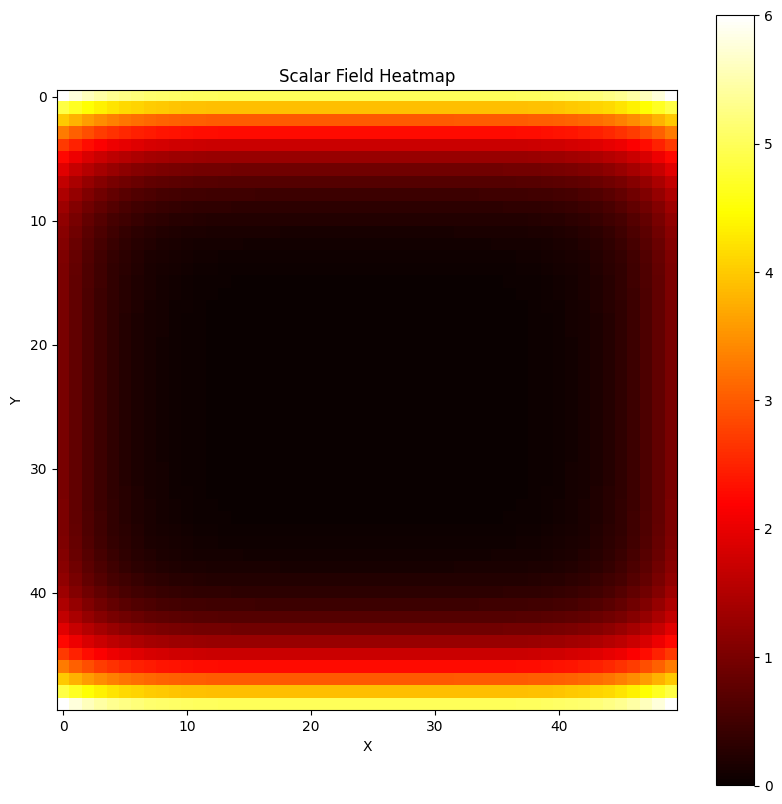

In [91]:
scalar_vis(scalar_field2)

Much better. How would the gradient to this look? Let us find out.

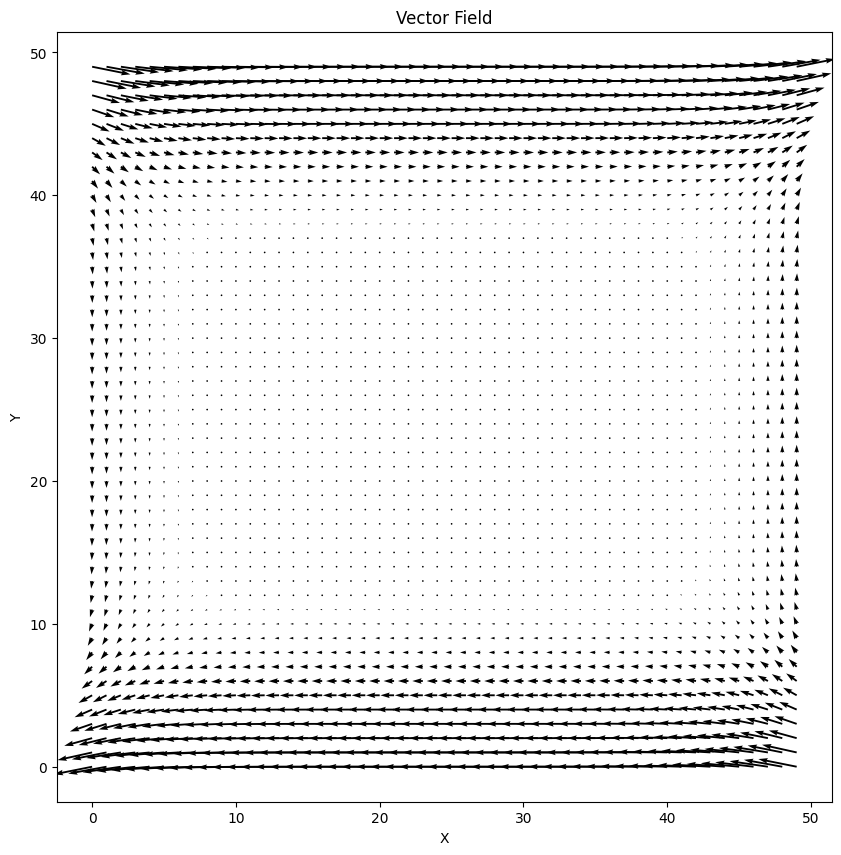

In [92]:
gradient_field2=grad(scalar_field2)
vector_vis(gradient_field2)

Overlay time!

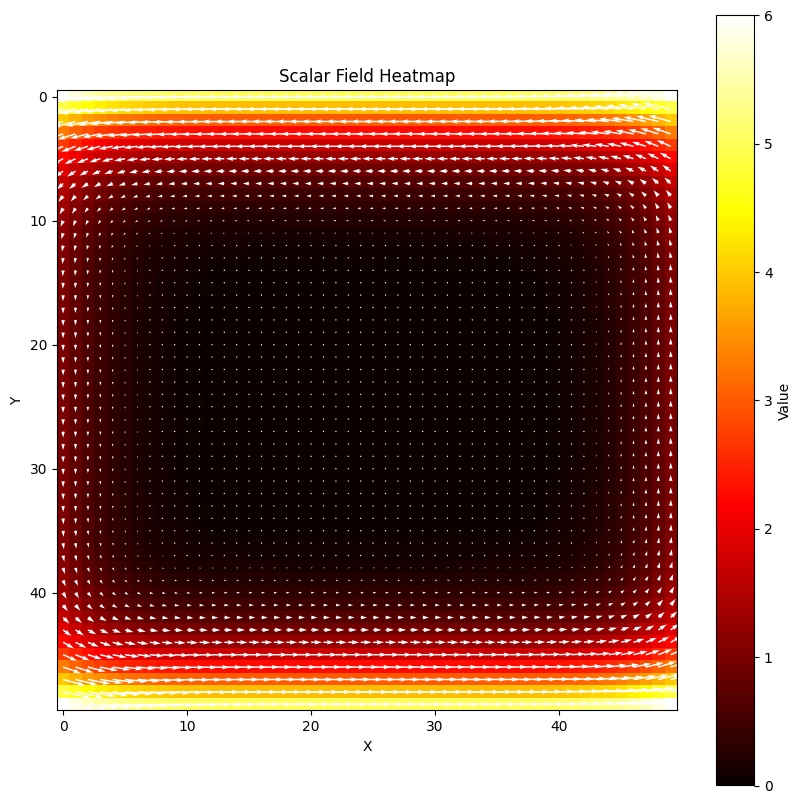

In [93]:
visualiser(scalar_field2, gradient_field2)

Now that we have a vector gradient. Let us see wht happens if we calculate the divergence of that!

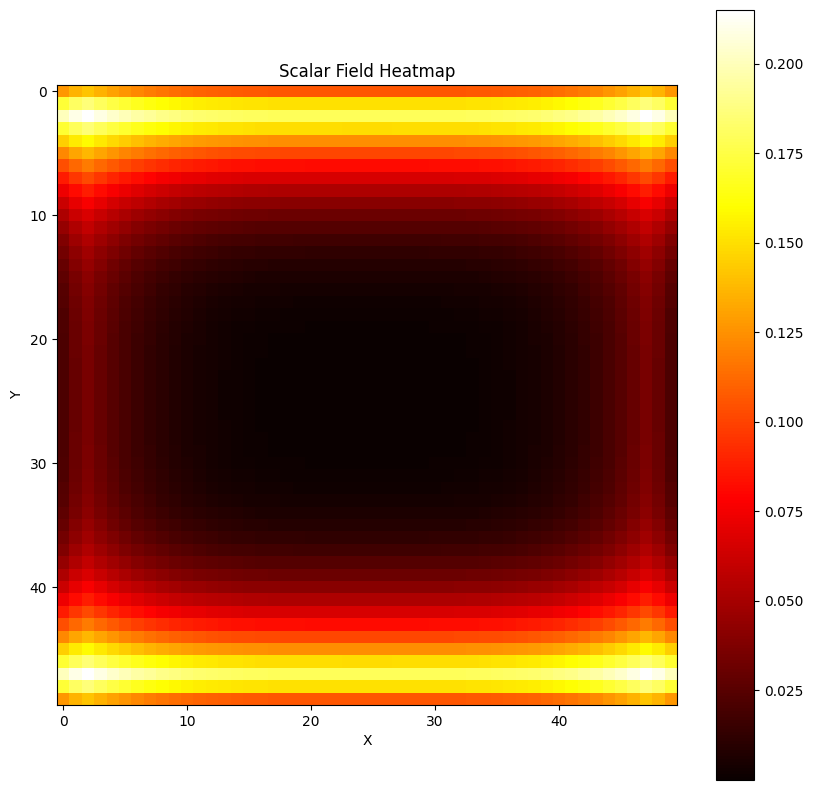

array([[0.12714616, 0.13605153, 0.14178742, ..., 0.14178742, 0.13605153,
        0.12714616],
       [0.17167301, 0.18057838, 0.18631427, ..., 0.18631427, 0.18057838,
        0.17167301],
       [0.20035249, 0.20925786, 0.21499375, ..., 0.21499375, 0.20925786,
        0.20035249],
       ...,
       [0.20035249, 0.20925786, 0.21499375, ..., 0.21499375, 0.20925786,
        0.20035249],
       [0.17167301, 0.18057838, 0.18631427, ..., 0.18631427, 0.18057838,
        0.17167301],
       [0.12714616, 0.13605153, 0.14178742, ..., 0.14178742, 0.13605153,
        0.12714616]])

In [103]:
divergence_field2=div(gradient_field2)
# visualiser(divergence_field2, gradient_field2)
scalar_vis(divergence_field2)

### Things to do:
#### 1) Play around with the equations to see how you can go from a scalar field generated from equations to a vector gradient which then can be used for generating a scalar divergence.   e.g.: $np.sin(X) * np.cos(Y)$
#### 2) Code up a curl function that calculates the curl of a vector field. Mind you, we are in the 2D world, so would the curl return a scalar or a vector? How would it be best represented?
#### 3) For different scalar functions f, visualise the curl of the divergence of the scalar function f.
#### 4) Visualise the LHS and RHS of the following compute rules for differential operators:
$$
\begin{align*}
(a):\quad&\nabla F(f) = F'(f)\nabla f \\
(b):\quad&\nabla \times(f\vec{v}) = f\nabla \times\vec{v} - \vec{v}\times\nabla f \\
(c):\quad&\nabla \cdot (\vec{v}_1\times\vec{v}_2) = \vec{v}_2\cdot\nabla \times\vec{v}_1 -\vec{v}_1\cdot\nabla \times\vec{v}_2 
\end{align*}
$$


In [104]:
def curl(field):
    dx = np.gradient(field[1])
    dy = np.gradient(field[0])
    return dx[0] - dy[1]

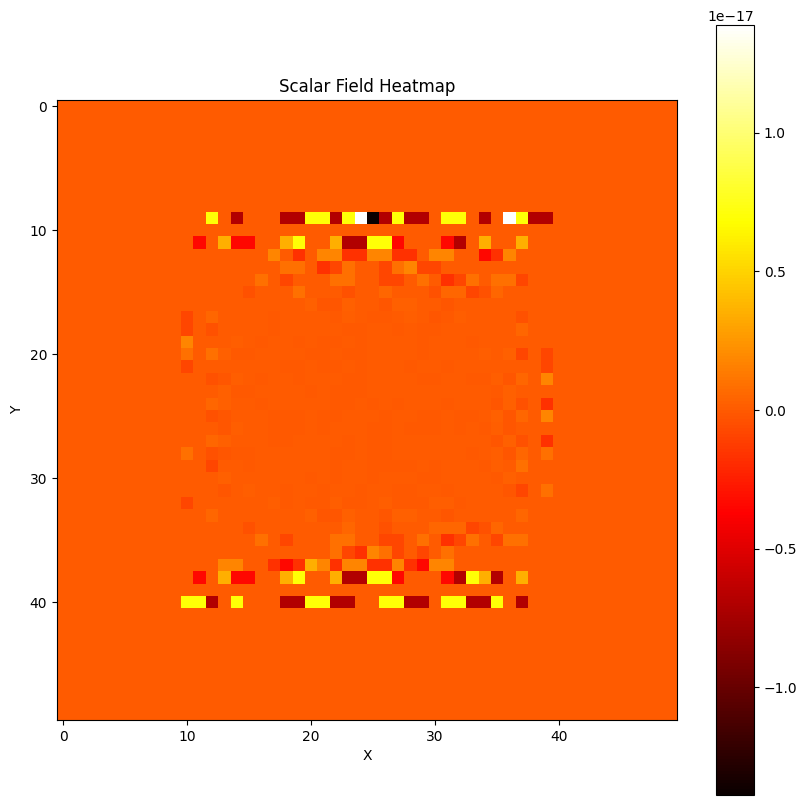

In [109]:
curl_field2 = curl(gradient_field2)
scalar_vis(curl_field2)

In [110]:
# 3. Impossible

In [ ]:
# 4.a


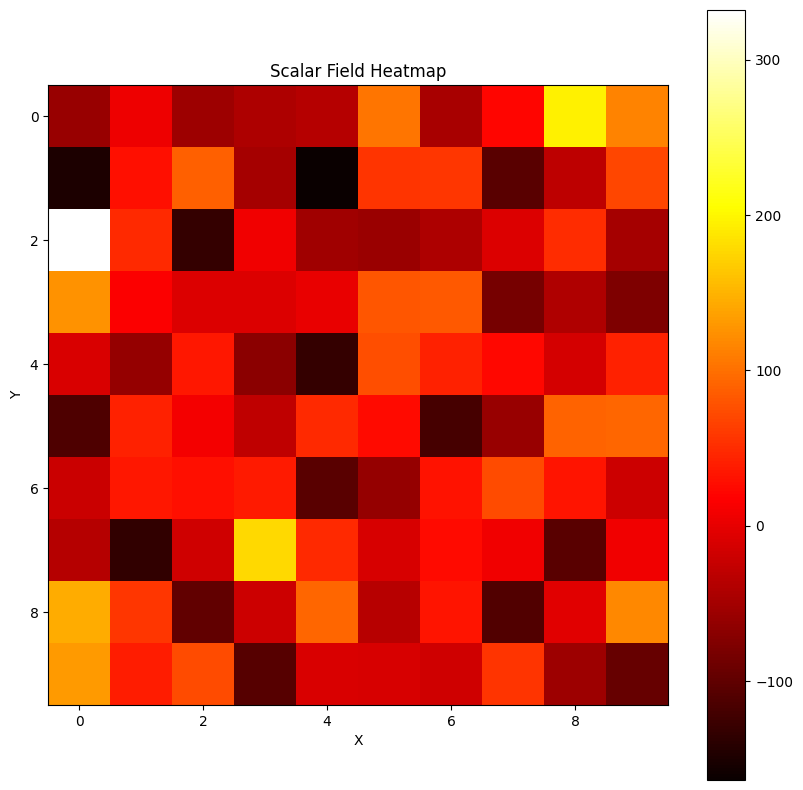

In [133]:
# 4.b
scalar_vis(curl(scalar_field * vector_field))
# scalar_field * curl(vector_field) - np.cross(vector_field, np.gradient(scalar_field))

In [134]:
(curl(grad(scalar_field)))

array([[ 3.55271368e-15,  1.77635684e-15,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 1.77635684e-15,  8.88178420e-16,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  3.55271368e-15,  0.00000000e+00,
         0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         8.88178420e-16,  0.00000000e+00, -1.77635684e-15,
         0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  1.33226763e-15, -1.77635684e-15,
        -3.55271368e-15,  0.00000000e+00,  3.55271368e-15,
         0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  3.55271368e-15,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        -8.88178420e-16,  0.00000000e+00,  3.55271368e-15,
         0.